In [1]:
import os 
import torch
import sys
import random
from tqdm.auto import tqdm
from safetensors.torch import save_file
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
import argparse

# sys.path.append('.')
from esd.utils.sd_utils import esd_sd_call
StableDiffusionPipeline.__call__ = esd_sd_call

from collections import defaultdict


/home/nessessence/anaconda3/envs/uul/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_sd_models(basemodel_id="CompVis/stable-diffusion-v1-4", torch_dtype=torch.bfloat16, device='cuda:0'):
    
    base_unet = UNet2DConditionModel.from_pretrained(basemodel_id, subfolder="unet").to(device, torch_dtype)
    base_unet.requires_grad_(False)
    
    esd_unet = UNet2DConditionModel.from_pretrained(basemodel_id, subfolder="unet").to(device, torch_dtype)
    pipe = StableDiffusionPipeline.from_pretrained(basemodel_id, unet=base_unet, torch_dtype=torch_dtype, use_safetensors=True).to(device)
    
    return pipe, base_unet, esd_unet






def update_output_stats(noise_pred_erase, noise_pred_general, timestep,
                        erase_concept="erase", general_concept="general"):
    global output_stats

    # Flatten to vectors
    erase_flat = noise_pred_erase.flatten(start_dim=0).detach().cpu()
    general_flat = noise_pred_general.flatten(start_dim=0).detach().cpu()

    # Norms
    norm_erase = torch.norm(erase_flat).item()
    norm_general = torch.norm(general_flat).item()

    # Dot product
    dot_val = torch.dot(erase_flat, general_flat).item()

    # Cosine similarity
    cosine_val = dot_val / (norm_erase * norm_general + 1e-8)

    # Store results grouped by timestep under each key
    output_stats[f"raw_{erase_concept}"][timestep].append(erase_flat)
    output_stats[f"raw_{general_concept}"][timestep].append(general_flat)
    output_stats[f"norm_{erase_concept}"][timestep].append(norm_erase)
    output_stats[f"norm_{general_concept}"][timestep].append(norm_general)
    output_stats[f"dot_{erase_concept}.{general_concept}"][timestep].append(dot_val)
    output_stats[f"cosine_{erase_concept}.{general_concept}"][timestep].append(cosine_val)

In [3]:
device = 'cuda:1'
torch_dtype = torch.bfloat16

num_inference_steps = 250
height=width=1024
batchsize = 1
guidance_scale = 3.0
timestep_cond = None

seed = random.randint(0, 2**15)

erase_concept = "Barrack Obama"
general_concept = "person"
pipe, base_unet, esd_unet = load_sd_models(basemodel_id="CompVis/stable-diffusion-v1-4", torch_dtype=torch_dtype, device=device)


pipe.set_progress_bar_config(disable=True)
pipe.scheduler.set_timesteps(num_inference_steps)


Loading pipeline components...:  57%|███████████████████████████████████████████▍                                | 4/7 [00:00<00:00,  6.35it/s]/home/nessessence/anaconda3/envs/uul/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Loading pipeline components...: 100%|████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00,  9.62it/s]


In [4]:
with torch.no_grad():
    
        erase_embeds, null_embeds = pipe.encode_prompt(prompt=erase_concept,
                                                       device=device,
                                                       num_images_per_prompt=batchsize,
                                                       do_classifier_free_guidance=True,
                                                       negative_prompt='')
                                                 
        erase_embeds = erase_embeds.to(device)
        null_embeds = null_embeds.to(device)
        
        general_embeds, _ = pipe.encode_prompt(prompt=general_concept,
                                                device=device,
                                                num_images_per_prompt=batchsize,
                                                do_classifier_free_guidance=True,
                                                negative_prompt='')
        base_embeds = general_embeds.to(device)
        

In [ ]:

# declare once outside the function
output_stats = defaultdict(lambda: defaultdict(list))
n_samples = 50

total_n =  n_samples * num_inference_steps
with tqdm(total=total_n, desc="Processing") as pbar:
    with torch.no_grad():
        for t_inferstep in range(0, num_inference_steps-1):
            t = pipe.scheduler.timesteps[t_inferstep]
            for _ in range(n_samples):
                # random t

                # print(f"t: {t}, t_inferstep: {t_inferstep}")

                # sample z_t with Pg ("person")
                z_t = pipe(general_concept, 
                        num_images_per_prompt=batchsize, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale, 
                        run_till_timestep=t_inferstep, generator=torch.Generator().manual_seed(seed), output_type='latent', height=height, width=width).images

                # 
                noise_pred_erase = pipe.unet(
                    z_t,
                    t,
                    encoder_hidden_states=erase_embeds,
                    timestep_cond=timestep_cond,
                    cross_attention_kwargs=None,
                    added_cond_kwargs=None,
                    return_dict=False,
                )[0][0]



                noise_pred_general = pipe.unet(
                    z_t,
                    t,
                    encoder_hidden_states=general_embeds,
                    timestep_cond=timestep_cond,
                    cross_attention_kwargs=None,
                    added_cond_kwargs=None,
                    return_dict=False,
                )[0][0]
                
                # print(noise_pred_erase.shape, noise_pred_general.shape) # [4, 128, 128], [4, 128, 128]

                update_output_stats(noise_pred_erase, noise_pred_general,timestep = t, erase_concept=erase_concept, general_concept=general_concept)

                # print(output_stats)
                
                pbar.update(1)
    # print(z_t.shape) # [1, 4, 64, 64] for 512x512 :::  [1, 4, 128, 128]

Processing:   2%|█▋                                                                                      | 236/12500 [05:17<4:35:12,  1.35s/it]


KeyboardInterrupt: 

In [ ]:
torch.save(update_output_stats, 'data_root/cache/tmp/sampling_stats_obama_person.pth')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def compute_means_and_ci(A, B=None, alpha=0.05):
    ## two-sided confidence intervals (alpha/2)
    """
    Compute means and confidence intervals for one or two groups.
    
    Args:
        A: Array of data for group A (required)
        B: Array of data for group B (optional, default=None)
        alpha: Significance level (default 0.05 for 95% CI)
    
    Returns:
        dict: Contains means, confidence intervals, margin of error, and other statistics
    """
    # Compute mean and CI for group A
    mean_A = np.mean(A)
    var_A = np.var(A, ddof=1)
    n_A = len(A)
    se_A = np.sqrt(var_A / n_A)
    
    # t-critical value for group A
    df_A = n_A - 1
    t_crit_A = stats.t.ppf(1 - alpha/2, df_A)
    margin_A = t_crit_A * se_A  # Margin of error
    ci_A = (mean_A - margin_A, mean_A + margin_A)
    
    result = {
        'mean_A': mean_A,
        'ci_A': ci_A,
        'margin_A': margin_A,  # Margin of error (t_crit * se)
        'se_A': se_A,
        'n_A': n_A,
        'df_A': df_A
    }
    
    # If group B is provided, compute additional statistics
    if B is not None:
        mean_B = np.mean(B)
        var_B = np.var(B, ddof=1)
        n_B = len(B)
        se_B = np.sqrt(var_B / n_B)
        
        # t-critical value for group B
        df_B = n_B - 1
        t_crit_B = stats.t.ppf(1 - alpha/2, df_B)
        margin_B = t_crit_B * se_B  # Margin of error
        ci_B = (mean_B - margin_B, mean_B + margin_B)
        
        # Difference statistics
        diff_mean = mean_A - mean_B
        se_diff = np.sqrt(var_A / n_A + var_B / n_B)
        
        # Degrees of freedom for difference (Welch-Satterthwaite)
        numerator = (var_A / n_A + var_B / n_B)**2
        denominator = ((var_A / n_A)**2 / (n_A - 1) + 
                       (var_B / n_B)**2 / (n_B - 1))
        df_diff = numerator / denominator
        
        t_crit_diff = stats.t.ppf(1 - alpha/2, df_diff)
        margin_diff = t_crit_diff * se_diff  # Margin of error for difference
        ci_diff = (diff_mean - margin_diff, diff_mean + margin_diff)
        
        # Add group B and difference statistics to result
        result.update({
            'mean_B': mean_B,
            'ci_B': ci_B,
            'margin_B': margin_B,  # Margin of error for B
            'se_B': se_B,
            'n_B': n_B,
            'df_B': df_B,
            'mean_diff': diff_mean,
            'ci_diff': ci_diff,
            'margin_diff': margin_diff,  # Margin of error for difference
            'se_diff': se_diff,
            'df_diff': df_diff
        })
    
    return result


def _to_int_timestep(t):
    try:
        return int(t.item())
    except Exception:
        return int(t)

def _series_from_output_stats(output_stats, key):
    """
    Returns sorted timesteps and lists of values per timestep for a given key.
    """
    if key not in output_stats:
        raise KeyError(f"Key '{key}' not found in output_stats")
    # normalize timestep keys to int and sort
    items = [(_to_int_timestep(t), output_stats[key][t]) for t in output_stats[key].keys()]
    items.sort(key=lambda x: x[0])
    timesteps = [t for t, _ in items]
    values_per_t = [np.array(v, dtype=float) for _, v in items]
    return timesteps, values_per_t

def plot_output_stats(output_stats, stat="cosine",
                      erase_concept="erase", general_concept="general",
                      alpha=0.05, figsize=(10, 6), plot_ci=True):
    """
    Plot mean ± CI over timesteps for:
      - stat in {'dot','cosine'}: one line for f'{stat}_{erase}.{general}'
      - stat == 'norm': two lines, f'norm_{erase}' and f'norm_{general}'
    Uses compute_means_and_ci(A, B=None, alpha) provided by the user.
    """
    assert stat in {"norm", "dot", "cosine"}, "stat must be one of {'norm','dot','cosine'}"
    plt.figure(figsize=figsize)

    if stat == "norm":
        key_e = f"norm_{erase_concept}"
        key_g = f"norm_{general_concept}"

        # erase
        ts_e, vals_list_e = _series_from_output_stats(output_stats, key_e)
        means_e, lo_e, hi_e = [], [], []
        for arr in vals_list_e:
            res = compute_means_and_ci(arr, alpha=alpha)
            means_e.append(res["mean_A"]); lo_e.append(res["ci_A"][0]); hi_e.append(res["ci_A"][1])

        # general
        ts_g, vals_list_g = _series_from_output_stats(output_stats, key_g)
        means_g, lo_g, hi_g = [], [], []
        for arr in vals_list_g:
            res = compute_means_and_ci(arr, alpha=alpha)
            means_g.append(res["mean_A"]); lo_g.append(res["ci_A"][0]); hi_g.append(res["ci_A"][1])

        # plot
        plt.plot(ts_e, means_e, label=f"‖{erase_concept}‖")
        if plot_ci:
            plt.fill_between(ts_e, lo_e, hi_e, alpha=0.2, linewidth=0)

        plt.plot(ts_g, means_g, label=f"‖{general_concept}‖")
        if plot_ci:
            plt.fill_between(ts_g, lo_g, hi_g, alpha=0.2, linewidth=0)

        ylabel = "Norm"

    else:
        key = f"{stat}_{erase_concept}.{general_concept}"
        ts, vals_list = _series_from_output_stats(output_stats, key)
        means, lo, hi = [], [], []
        for arr in vals_list:
            res = compute_means_and_ci(arr, alpha=alpha)
            means.append(res["mean_A"]); lo.append(res["ci_A"][0]); hi.append(res["ci_A"][1])

        plt.plot(ts, means, label=key.replace("_", " "))
        if plot_ci:
            plt.fill_between(ts, lo, hi, alpha=0.2, linewidth=0)

        ylabel = "Dot product" if stat == "dot" else "Cosine similarity"

    plt.xlabel("Timestep")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} over timesteps")
    plt.legend()
    plt.tight_layout()
    plt.show()


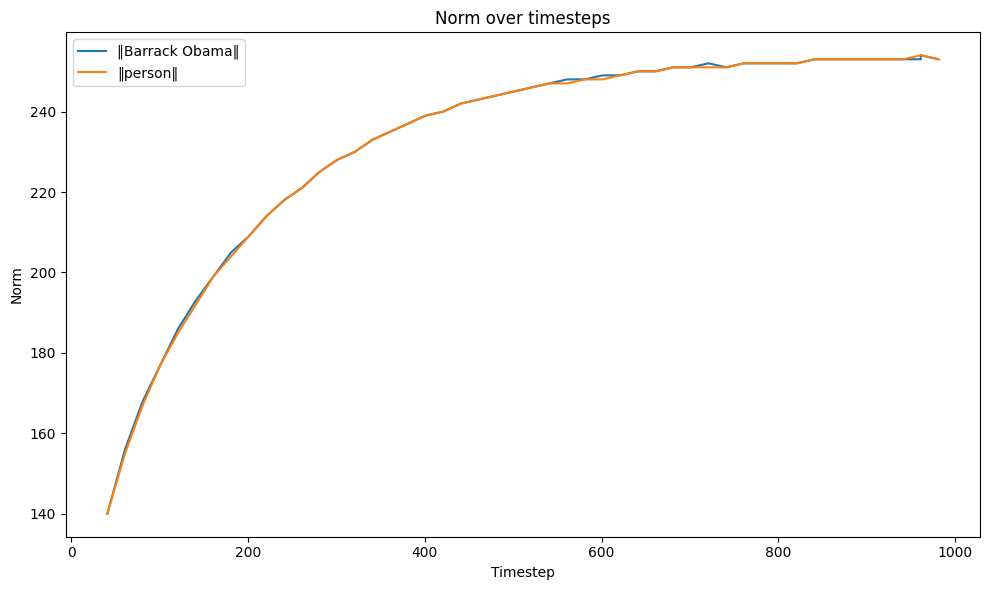

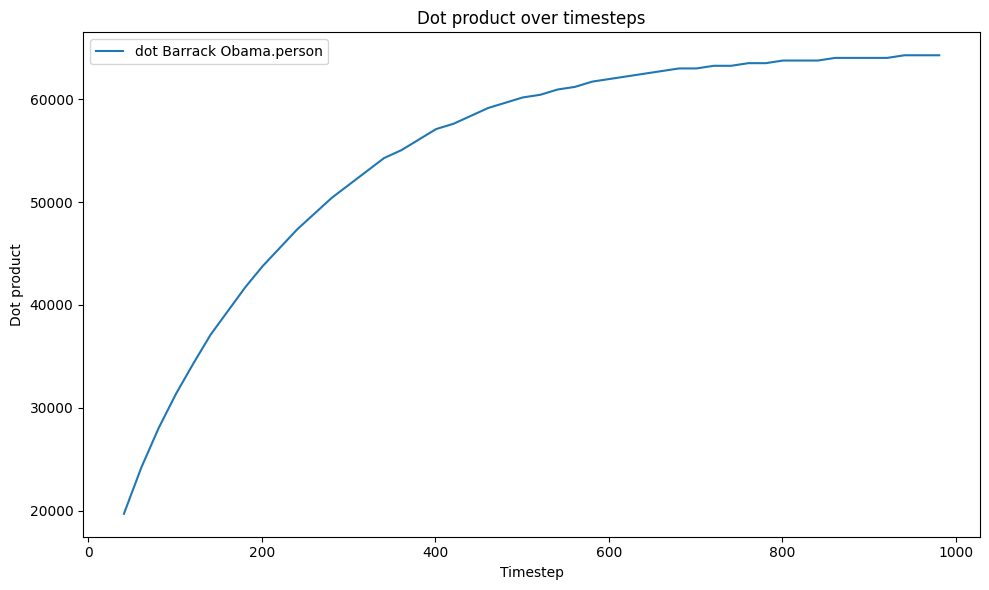

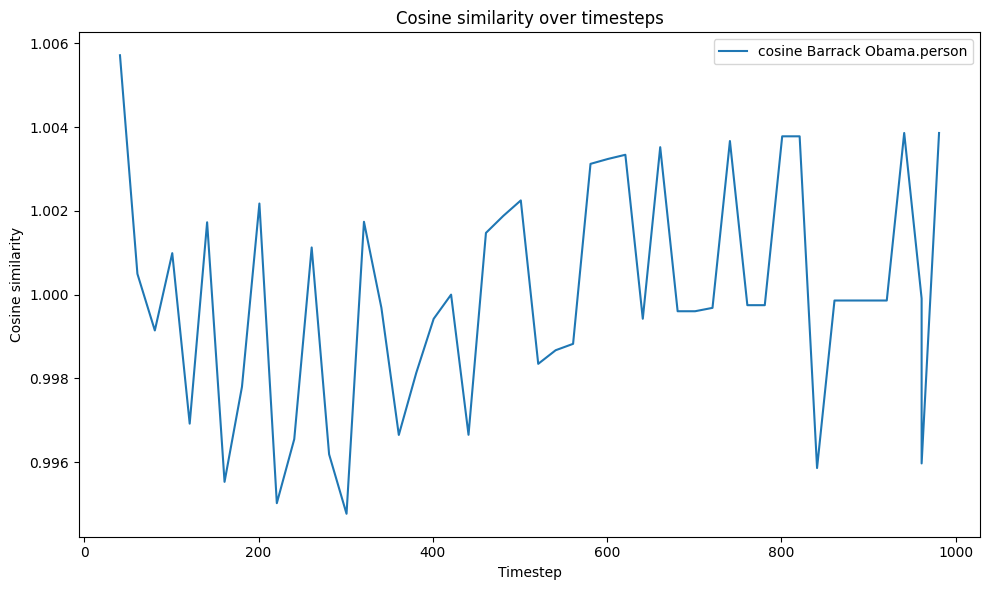

In [ ]:
# Example calls:
plot_output_stats(output_stats, stat="norm",   erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="dot",    erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="cosine", erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
